In [ ]:
import pandas as pd

In [ ]:
dados = pd.read_csv('/content/emp_automovel (1).csv')
dados.head(10)

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0
5,15750.000000,1286.550000,12.157324,0,2.0,0.496792,0.638649,0.513171,0.117428,1750.0,0
6,18000.000000,3119.400000,4.000000,0,2.0,0.210867,0.170438,0.513171,0.117428,969.0,0
7,15750.000000,3428.100000,8.000000,1,2.0,0.514392,0.540711,0.513171,0.018600,2421.0,0
8,22500.000000,2722.188351,12.157324,0,2.0,0.617446,0.774146,0.513171,0.204400,0.0,0
9,16855.246324,2722.188351,12.157324,0,2.0,0.501213,0.557860,0.513171,0.117428,0.0,0


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [ ]:
x = dados.drop(['inadimplente'], axis = 1)
y = dados['inadimplente']

In [ ]:
x

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000
...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000


In [ ]:
y

,inadimplente
0,0
1,0
2,0
3,0
4,0
...,...
54020,1
54021,1
54022,1
54023,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
modelo = DecisionTreeClassifier()

In [ ]:
#acuracia 100% = overfit

modelo.fit(x,y)
modelo.score(x,y)

1.0

In [ ]:
print(f'Acuracia inicial é de {modelo.score(x,y)} ')

Acuracia inicial é de 1.0 


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#Basicamente dividimos em 3 partes treino, teste e validação.
#stratify - extração dos dados acontece de forma padronizada, sem inviesar o modelo pegando + amosstras de uma categoria ou outra
#test_size define a porcentagem separada para teste 15%


x,x_teste,y,y_teste = train_test_split(x, y, test_size = 0.15, stratify= y, random_state=5)
x_treino,x_validacao,y_treino,y_validacao = train_test_split(x,y,stratify= y, random_state=5)

In [ ]:
# max_depht - defini o numero de divisoes(pergunta) que o modelo faz quanto maior, mais o modelo se ajusta
#ideal é manter equilibrio entre ajuste e validaçãp

modelo = DecisionTreeClassifier(max_depth=10)

modelo.fit(x_treino, y_treino)

print(f'Acuracia inicial é de {modelo.score(x_treino,y_treino)}')
print(f'Acuracia de validação é de {modelo.score(x_validacao,y_validacao)}')

Acuracia inicial é de 0.9206445993031359
Acuracia de validação é de 0.9058444386377493


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_previsto = modelo.predict(x_validacao)
matriz_confusao = confusion_matrix(y_validacao, y_previsto)
matriz_confusao

array([[10355,   124],
       [  957,    45]])

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

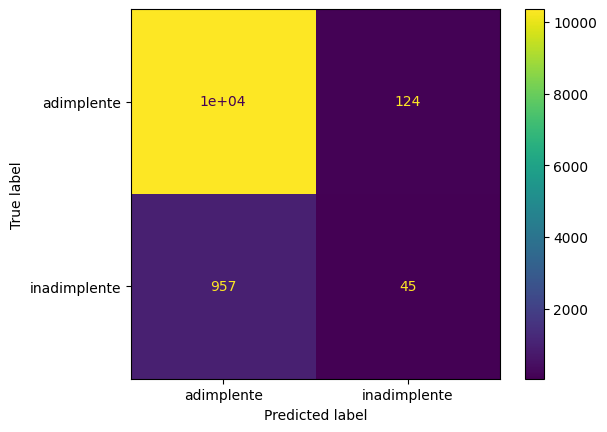

In [ ]:
# Eixo X representa as previsões do modelo
# Eixo Y representa os valores reais
# Na coluna "adimplente" (previsão), o modelo acertou 7519 casos, mas classificou 52 como inadimplentes (falso positivo) - na verdade eram bons pagadores
# Na coluna "inadimplente" (previsão), o modelo classificou 701 como inadimplentes, mas na verdade eram adimplentes (falso positivo);
#o modelo acertou 23 casos de inadimplência (falso negativo)

vizualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,display_labels=['adimplente','inadimplente'])
vizualizacao.plot();

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(f'Acurácia {accuracy_score(y_validacao,y_previsto)}')

Acurácia 0.9058444386377493


In [ ]:
from sklearn.metrics import precision_score, recall_score

In [ ]:
print(f' Precisão {precision_score(y_validacao,y_previsto)} ')
print(f'Recall {recall_score(y_validacao,y_previsto)} ')

 Precisão 0.26627218934911245 
Recall 0.04491017964071856 


In [ ]:
from sklearn.metrics import f1_score

In [ ]:
print(f'F1 -score {f1_score(y_validacao,y_previsto)}')

F1 -score 0.07685738684884715


In [ ]:
from sklearn.metrics import RocCurveDisplay

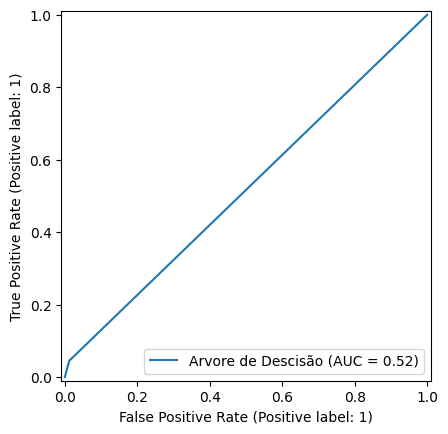

In [ ]:
RocCurveDisplay.from_predictions(y_validacao, y_previsto,name = 'Arvore de Descisão');

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
print(f'AUC: {roc_auc_score(y_validacao, y_previsto)}')

AUC: 0.5165384947254075


In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

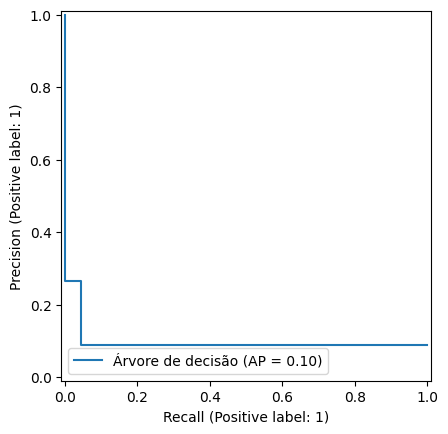

In [ ]:
PrecisionRecallDisplay.from_predictions(y_validacao, y_previsto, name = 'Árvore de decisão');

In [ ]:
from sklearn.metrics import average_precision_score

In [ ]:
print(f'AP: {average_precision_score(y_validacao, y_previsto)}')

AP: 0.09531344029702743


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_validacao, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.27      0.04      0.08      1002

    accuracy                           0.91     11481
   macro avg       0.59      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



In [ ]:
from sklearn.model_selection import cross_validate, KFold

In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo,x,y,cv = kf)
cv_resultados


{'fit_time': array([0.42778945, 0.42844725, 0.40109253, 0.43596315, 0.41503143]),
 'score_time': array([0.00609279, 0.00560069, 0.00546813, 0.00543952, 0.01378226]),
 'test_score': array([0.91366358, 0.90831882, 0.90744774, 0.9135453 , 0.89939024])}

In [ ]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'Intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

Intervalo de confiança: [0.8980331449166615, 0.9189131240910943]


In [ ]:
def intervalo_confianca(resultados):
  media = resultados['test_score'].mean()
  desvio_padrao = resultados['test_score'].std()
  print(f'Intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

In [ ]:
#definindo qual tipo de metrica quero extrair o intervalo de confiança COM SCORING

modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo,x,y,cv = kf,scoring = 'recall' )
cv_resultados

{'fit_time': array([0.69570065, 0.88226342, 0.41750908, 0.40251517, 0.30090714]),
 'score_time': array([0.01741624, 0.02114844, 0.00915766, 0.00644231, 0.0061903 ]),
 'test_score': array([0.02906209, 0.01856436, 0.0196802 , 0.01827676, 0.02312139])}

In [ ]:
intervalo_confianca(cv_resultados)

Intervalo de confiança: [0.013649347407257664, 0.029832568636421898]


In [ ]:
dados['inadimplente'].value_counts(normalize = True)

,proportion
inadimplente,
0,0.912707
1,0.087293


In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10 )
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state= 5)
cv_resultados = cross_validate(modelo,x,y,cv = skf, scoring = 'recall')



In [ ]:
intervalo_confianca(cv_resultados)

Intervalo de confiança: [0.021021222200699786, 0.03535282395731342]


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversample = SMOTE()
x_balanceado, y_balanceado = oversample.fit_resample(x, y)

In [ ]:
y_balanceado.value_counts(normalize = True)

,proportion
inadimplente,
0,0.5
1,0.5


In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x_balanceado, y_balanceado, cv=skf, scoring = 'recall')

In [ ]:
intervalo_confianca(cv_resultados)

Intervalo de confiança: [0.7201803235162261, 0.7650265977071553]


##papiline oversampling


In [ ]:
from imblearn.pipeline import Pipeline as imbpipeline

In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring = 'recall')

In [ ]:
intervalo_confianca(cv_resultados)

Intervalo de confiança: [0.21020926284086444, 0.30015029394756404]


##Undersampling com Near Miss

In [ ]:
from imblearn.under_sampling import NearMiss

In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])

In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring = 'recall')

In [ ]:
intervalo_confianca(cv_resultados)

Intervalo de confiança: [0.6249520001834334, 0.6985532192897312]


In [ ]:
undersample = NearMiss(version=3)
x_balanceado, y_balanceado = undersample.fit_resample(x, y)

In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_teste)

In [ ]:
print(classification_report(y_teste, y_previsto))

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.71      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



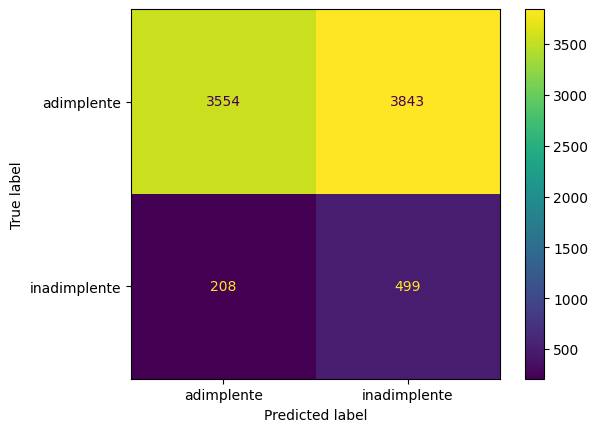

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto,display_labels=['adimplente','inadimplente']);